<a href="https://colab.research.google.com/github/snipverse/GenAI/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [11]:
(X_train, _), (_, _) = mnist.load_data()

X_train = (X_train - 127.5) / 127.5
X_train = X_train.reshape(-1, 28*28)

In [12]:
def build_generator():
    model = Sequential([
        Dense(256, input_dim=100),
        LeakyReLU(0.2),
        Dense(512),
        LeakyReLU(0.2),
        Dense(28*28, activation='tanh')
    ])
    return model

generator = build_generator()

In [13]:
def build_discriminator():
    model = Sequential([
        Dense(512, input_dim=28*28),
        LeakyReLU(0.2),
        Dense(256),
        LeakyReLU(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(0.0002, 0.5),
        metrics=['accuracy']
    )
    return model

discriminator = build_discriminator()

In [14]:

discriminator.trainable = False

gan = Sequential([generator, discriminator])
gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5)
)

In [15]:
def train_gan(epochs=2000, batch_size=64):
    for epoch in range(epochs):
        # Train Discriminator
        real_imgs = X_train[np.random.randint(0, X_train.shape[0], batch_size)]
        noise = np.random.normal(0, 1, (batch_size, 100))
        fake_imgs = generator.predict(noise, verbose=0)

        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
        d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))

        # Train Generator
        noise = np.random.normal(0, 1, (batch_size, 100))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        if epoch % 500 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss_real[0]:.4f} | G Loss: {g_loss:.4f}")

In [16]:
def generate_images():
    noise = np.random.normal(0, 1, (10, 100))
    images = generator.predict(noise, verbose=0)
    images = images.reshape(10, 28, 28)

    plt.figure(figsize=(8,4))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.axis('off')
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.8717 | G Loss: 0.6101
Epoch 500 | D Loss: 4.5467 | G Loss: 0.0071
Epoch 1000 | D Loss: 5.1563 | G Loss: 0.0036
Epoch 1500 | D Loss: 5.5132 | G Loss: 0.0024


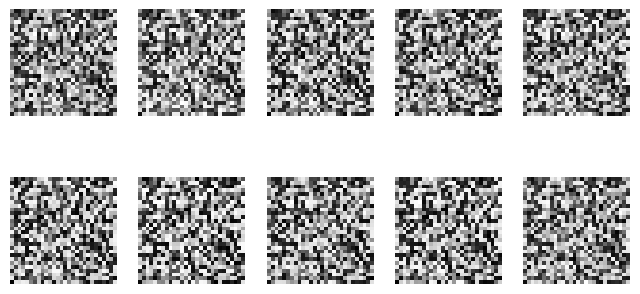

In [9]:

train_gan()
generate_images()